[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/15_adversarial_search/notebooks/01_juegos_y_arboles.ipynb)

# Juegos y Árboles

**Módulo 15 — Búsqueda Adversarial · Notebook 01**

---

## ¿De qué trata este notebook?

Este notebook cubre la **modelación de juegos de dos jugadores** desde primeros principios.
No asume que hayas leído las notas de clase; todo el razonamiento está aquí.

**Lo que vas a construir y explorar:**

1. Una interfaz formal `Juego` en Python (paralela a la interfaz `Problema` de módulo 13).
2. Dos juegos concretos: **Nim** y **Tic-tac-toe**, completamente implementados.
3. La función `construir_arbol` que expande el árbol completo de un juego.
4. Análisis de complejidad: contar nodos, medir factores de ramificación.
5. Visualización del árbol de Nim(1,2) con 12 nodos y valores minimax.
6. La propiedad de suma cero probada empíricamente.
7. (Ir más lejos) Juegos de N jugadores: más allá del esquema MAX/MIN.

**Relación con las notas de clase:** secciones 15.1 (¿Qué es un juego?) y 15.2
(Árboles de juego y complejidad).

**Prerequisitos:** Python básico (clases, recursión), módulo 13 (búsqueda simple).

---

### ¿Por qué estudiar juegos?

Los juegos son el banco de pruebas histórico de la IA. Desde que Shannon describió
el ajedrez como problema de búsqueda en 1950, los juegos de dos jugadores han
servido para:

- **Forzar precisión formal**: un juego tiene reglas exactas, lo que elimina la ambigüedad.
- **Escalar la dificultad controladamente**: Nim de 2 fichas vs. Go 19×19.
- **Probar que los algoritmos funcionan**: existe una respuesta correcta verificable.

El salto conceptual respecto a búsqueda en módulo 13 es este:

> En búsqueda simple, el agente controla **todas** las acciones.
> En juegos, el entorno incluye un **oponente adversarial** que elige acciones
> para perjudicarnos.

Esto cambia todo: ya no basta encontrar un camino al estado meta — hay que
encontrar una **estrategia** que funcione sin importar lo que haga el oponente.

In [3]:
# Solo en Colab — en entorno local estas librerías ya deben estar instaladas
import sys
if "google.colab" in sys.modules:
    !pip install -q numpy matplotlib

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from abc import ABC, abstractmethod
import random
import time

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

COLORS = {
    "max":      "#2E86AB",   # azul — nodos MAX
    "min":      "#E94F37",   # rojo — nodos MIN
    "win":      "#27AE60",   # verde — terminal ganador para MAX
    "lose":     "#7F8C8D",   # gris — terminal perdedor para MAX
    "draw":     "#F39C12",   # naranja — empate
    "optimal":  "#27AE60",   # verde — arista óptima
    "edge":     "#2C3E50",   # oscuro — arista normal
}

print("Dependencias cargadas correctamente.")

Dependencias cargadas correctamente.


---
## Parte 1: ¿Qué es un juego?

### De búsqueda a juegos

En el módulo 13 modelamos problemas de búsqueda con la interfaz:

```
Problema = (estado_inicial, acciones, resultado, es_meta, costo)
```

Un juego de dos jugadores extiende esta idea con varios ingredientes nuevos.
La definición formal tiene **siete componentes**:

| Componente | Notación | Descripción |
|-----------|----------|-------------|
| Estado inicial | $s_0$ | Configuración al comienzo del juego |
| Función de jugador | $\text{PLAYER}(s)$ | Qué jugador mueve en estado $s$ |
| Función de acciones | $\text{ACTIONS}(s)$ | Movimientos legales en $s$ |
| Función de transición | $\text{RESULT}(s, a)$ | Estado resultante de hacer $a$ en $s$ |
| Prueba terminal | $\text{TERMINAL}(s)$ | ¿Terminó el juego? |
| Función de utilidad | $\text{UTILITY}(s, p)$ | Valor numérico del estado terminal para el jugador $p$ |
| Conjunto de jugadores | $\{MAX, MIN\}$ | (en juegos de 2 jugadores) |

### La convención MAX / MIN

Llamamos **MAX** al agente que controla la IA (nosotros queremos maximizar su utilidad)
y **MIN** al oponente (que tratará de minimizarla).

Esta convención es arbitraria pero universal. Permite definir la utilidad desde
la perspectiva de MAX:

$$\text{UTILITY}(s, \text{MAX}) = +1 \text{ (victoria)}, \quad 0 \text{ (empate)}, \quad -1 \text{ (derrota)}$$

### Comparación con búsqueda simple

```
Búsqueda simple:   Problema(estado_inicial, acciones, resultado, es_meta, costo)
Juego:             Juego(estado_inicial, jugador, acciones, resultado, terminal, utilidad)
```

Las diferencias clave:
- **`jugador`**: no existía — el agente siempre controlaba todo.
- **`utilidad`**: reemplaza a `es_meta + costo`, pero solo se evalúa en terminales.
- **`terminal`**: reemplaza a `es_meta` (el juego puede terminar por empate o límite).

In [6]:
class Juego(ABC):
    """
    Interfaz base para juegos de dos jugadores suma-cero.

    Cualquier juego concreto debe implementar los seis métodos abstractos.
    La convención es:
      - MAX es el agente que buscamos optimizar.
      - MIN es el oponente (adversario).
      - utilidad() retorna valores desde la perspectiva de MAX:
          +1 = gana MAX, -1 = pierde MAX, 0 = empate.
    """

    @abstractmethod
    def estado_inicial(self):
        """Retorna el estado inicial del juego."""
        pass

    @abstractmethod
    def jugador(self, estado):
        """Retorna 'MAX' o 'MIN' según de quién es el turno."""
        pass

    @abstractmethod
    def acciones(self, estado):
        """Retorna lista de acciones legales desde estado."""
        pass

    @abstractmethod
    def resultado(self, estado, accion):
        """Retorna el nuevo estado tras aplicar accion en estado."""
        pass

    @abstractmethod
    def terminal(self, estado):
        """Retorna True si el juego terminó en este estado."""
        pass

    @abstractmethod
    def utilidad(self, estado, jugador='MAX'):
        """
        Retorna la utilidad numérica desde la perspectiva de jugador.
        Solo se llama en estados terminales.
        """
        pass


print("Clase abstracta Juego definida.")
print("Métodos requeridos:", [m for m in dir(Juego) if not m.startswith('_')])

Clase abstracta Juego definida.
Métodos requeridos: ['acciones', 'estado_inicial', 'jugador', 'resultado', 'terminal', 'utilidad']


---
## Parte 2: Nim — el juego de los palitos

### Reglas completas

**Nim** es uno de los juegos más antiguos y estudiados de la teoría de juegos
(su análisis matemático completo data de 1901, por Charles Bouton).

**Configuración:** Hay $k$ pilas, con $n_1, n_2, \ldots, n_k$ fichas respectivamente.

**Turno:** El jugador en turno elige **una** pila (que no esté vacía) y retira
**al menos una** ficha de esa pila. Puede retirar todas si quiere.

**Fin:** El jugador que retire la **última ficha** gana.
(Existe una variante donde pierde — se llama "Misère Nim" — pero aquí usamos la original.)

### Ejemplo de partida: Nim([1, 2])

```
Estado: (1, 2)  — pila A tiene 1 ficha, pila B tiene 2

MAX elige retirar 1 de pila B → (1, 1)
MIN elige retirar 1 de pila A → (0, 1)
MAX elige retirar 1 de pila B → (0, 0)  ← MAX tomó la última ficha → MAX GANA
```

### ¿Por qué Nim es un buen juego de aprendizaje?

1. **Estado simple**: una tupla de enteros.
2. **Árbol pequeño pero no trivial**: Nim(1,2) tiene solo 12 nodos — lo podemos dibujar.
3. **Tiene solución matemática conocida** (nim-sum XOR), lo que nos permite verificar
   que nuestro algoritmo encuentra la respuesta correcta.
4. **Escalable**: Nim(3,3,3) tiene miles de nodos — suficiente para medir costos.

### La función `jugador` en Nim

Necesitamos determinar de quién es el turno solo a partir del estado.
Observación clave: el número de fichas disminuye con cada movimiento.
Si empezamos con $S_0 = \sum_i n_i$ fichas y MAX mueve primero:

- Cuando quedan $S$ fichas con $S \equiv S_0 \pmod{2}$ → turno de MAX (mismo turno que el inicio)
- Cuando quedan $S$ fichas con $S \not\equiv S_0 \pmod{2}$ → turno de MIN

Esto funciona porque cada jugada retira al menos 1 ficha, alternando la paridad.

In [8]:
class Nim(Juego):
    """
    Juego de Nim para k pilas.

    Reglas: k pilas de fichas. En tu turno, retira >= 1 ficha de exactamente
    una pila. El jugador que retire la ultima ficha GANA.

    Estado: tupla de enteros (n_1, n_2, ..., n_k)
    Accion: (pile_idx, amount) — pila de la que se retira y cuántas fichas
    Utilidad: +1 si gana MAX, -1 si pierde MAX (perspectiva de MAX)
    """

    def __init__(self, pilas_iniciales):
        self.pilas_iniciales = tuple(pilas_iniciales)
        self._suma_inicial = sum(self.pilas_iniciales)

    def estado_inicial(self):
        return self.pilas_iniciales

    def jugador(self, estado):
        """
        Determina el turno por paridad de fichas restantes.

        Si la suma actual tiene la misma paridad que la suma inicial,
        es el turno de MAX (quien mueve primero). En caso contrario, MIN.

        Por ejemplo con Nim([1,2]): suma_inicial = 3 (impar).
          Estado (1,2): suma=3, impar==impar → MAX
          Estado (0,2): suma=2, par  ≠ impar → MIN
          Estado (1,1): suma=2, par  ≠ impar → MIN
        """
        suma_actual = sum(estado)
        if suma_actual % 2 == self._suma_inicial % 2:
            return "MAX"
        else:
            return "MIN"

    def acciones(self, estado):
        """
        Genera todas las jugadas legales: (pile_idx, cantidad) para toda
        pila i con al menos 1 ficha, y toda cantidad de 1 a estado[i].
        """
        moves = []
        for i, pila in enumerate(estado):
            for cant in range(1, pila + 1):
                moves.append((i, cant))
        return moves

    def resultado(self, estado, accion):
        """Aplica la accion: resta `amount` fichas de la pila `pile_idx`."""
        pile_idx, amount = accion
        nuevo = list(estado)
        nuevo[pile_idx] -= amount
        return tuple(nuevo)

    def terminal(self, estado):
        """El juego termina cuando todas las pilas están vacías."""
        return all(p == 0 for p in estado)

    def utilidad(self, estado, jugador='MAX'):
        """
        En Nim normal (no Misère), el jugador que tomó la última ficha GANA.

        Cuando se llama a utilidad(), el estado es (0,0,...,0) y alguien
        acaba de hacer el último movimiento. Ese jugador fue quien movió
        ANTES de llegar al estado terminal — es decir, el jugador cuyo
        turno NO es ahora.

        Lógica:
          - Si ahora le toca a MAX en el terminal (0,...,0), significa que
            MIN tomó la última ficha → MIN ganó → MAX pierde → retorna -1.
          - Si ahora le toca a MIN, entonces MAX tomó la última ficha → MAX
            ganó → retorna +1.

        Siempre retorna desde la perspectiva de MAX.
        """
        turno_actual = self.jugador(estado)
        if turno_actual == "MAX":
            return -1   # MAX sería el siguiente en mover pero no puede → MAX perdió
        else:
            return +1   # MIN sería el siguiente en mover pero no puede → MIN perdió

    def __repr__(self):
        return f"Nim({list(self.pilas_iniciales)})"


print("Clase Nim definida.")

Clase Nim definida.


In [9]:
# --- Test de la clase Nim ---

nim12 = Nim([1, 2])
s0 = nim12.estado_inicial()

print(f"Estado inicial:          {s0}")
print(f"Jugador en turno:        {nim12.jugador(s0)}")
print(f"Acciones disponibles:    {nim12.acciones(s0)}")
print(f"¿Es terminal?            {nim12.terminal(s0)}")

# Simular el ejemplo de la partida del texto
print("\n--- Simulación de partida ejemplo ---")
s1 = nim12.resultado(s0, (1, 1))   # MAX retira 1 de pila B
print(f"Tras MAX retirar 1 de B: {s1}  | Jugador: {nim12.jugador(s1)}")

s2 = nim12.resultado(s1, (0, 1))   # MIN retira 1 de pila A
print(f"Tras MIN retirar 1 de A: {s2}  | Jugador: {nim12.jugador(s2)}")

s3 = nim12.resultado(s2, (1, 1))   # MAX retira 1 de pila B (última ficha)
print(f"Tras MAX retirar 1 de B: {s3}  | ¿Terminal? {nim12.terminal(s3)}")
print(f"Utilidad (perspectiva MAX): {nim12.utilidad(s3)}  → +1 significa MAX ganó")

# Verificar que la función jugador es consistente
print("\n--- Verificación de jugador() ---")
for estado in [(1,2), (0,2), (1,1), (1,0), (0,1), (0,0)]:
    print(f"  {estado}: {nim12.jugador(estado)}")

Estado inicial:          (1, 2)
Jugador en turno:        MAX
Acciones disponibles:    [(0, 1), (1, 1), (1, 2)]
¿Es terminal?            False

--- Simulación de partida ejemplo ---
Tras MAX retirar 1 de B: (1, 1)  | Jugador: MIN
Tras MIN retirar 1 de A: (0, 1)  | Jugador: MAX
Tras MAX retirar 1 de B: (0, 0)  | ¿Terminal? True
Utilidad (perspectiva MAX): 1  → +1 significa MAX ganó

--- Verificación de jugador() ---
  (1, 2): MAX
  (0, 2): MIN
  (1, 1): MIN
  (1, 0): MAX
  (0, 1): MAX
  (0, 0): MIN


---
## Parte 3: Tic-tac-toe (Gato)

### Reglas

Tablero 3×3. Los jugadores se alternan colocando fichas:
- MAX coloca **X**
- MIN coloca **O**

Gana el primero en completar una línea (fila, columna o diagonal) con sus fichas.
Si el tablero se llena sin ganador, es empate.

### Representación del estado

Representamos el tablero como una tupla de 9 strings:

```
índices:   0 | 1 | 2
           ---------
           3 | 4 | 5
           ---------
           6 | 7 | 8
```

Cada celda es `''` (vacía), `'X'` o `'O'`.

### ¿Cómo saber de quién es el turno?

Simple: contamos las fichas. Si hay igual cantidad de X y O, es el turno de MAX (X).
Si hay una X más que O, es el turno de MIN (O).

### Complejidad

El árbol completo tiene a lo sumo $9! = 362\,880$ nodos (muchos menos en la práctica
porque el juego termina antes de llenar el tablero). Para los ejercicios de este
notebook, Nim(1,2) es más manejable visualmente; Tic-tac-toe aparece en el Notebook 02.

In [11]:
class TicTacToe(Juego):
    """
    Tic-tac-toe (gato) en tablero 3x3.

    Estado: tupla de 9 strings ('', 'X', 'O')
    Posiciones:
      0 | 1 | 2
      ---------
      3 | 4 | 5
      ---------
      6 | 7 | 8

    MAX juega X, MIN juega O.
    Utilidad: +1 gana X, -1 gana O, 0 empate.
    """

    # Todas las líneas ganadoras: filas, columnas, diagonales
    LINEAS = [
        [0, 1, 2], [3, 4, 5], [6, 7, 8],  # filas
        [0, 3, 6], [1, 4, 7], [2, 5, 8],  # columnas
        [0, 4, 8], [2, 4, 6],             # diagonales
    ]

    def estado_inicial(self):
        return tuple([''] * 9)

    def jugador(self, estado):
        """
        Si hay igual número de X y O, es turno de MAX (X mueve primero).
        Si hay una X más, es turno de MIN.
        """
        xs = estado.count('X')
        os = estado.count('O')
        return 'MAX' if xs == os else 'MIN'

    def acciones(self, estado):
        """Celdas vacías disponibles."""
        return [i for i, celda in enumerate(estado) if celda == '']

    def resultado(self, estado, accion):
        """Coloca la ficha del jugador actual en la posicion `accion`."""
        ficha = 'X' if self.jugador(estado) == 'MAX' else 'O'
        nuevo = list(estado)
        nuevo[accion] = ficha
        return tuple(nuevo)

    def _ganador(self, estado):
        """Retorna 'X', 'O' o None según quién haya completado una línea."""
        for linea in self.LINEAS:
            fichas = [estado[i] for i in linea]
            if fichas[0] != '' and fichas[0] == fichas[1] == fichas[2]:
                return fichas[0]
        return None

    def terminal(self, estado):
        """El juego termina si hay ganador o el tablero está lleno."""
        return self._ganador(estado) is not None or '' not in estado

    def utilidad(self, estado, jugador='MAX'):
        """Utilidad desde perspectiva de MAX: +1 X gana, -1 O gana, 0 empate."""
        ganador = self._ganador(estado)
        if ganador == 'X':
            return +1
        elif ganador == 'O':
            return -1
        return 0

    def mostrar(self, estado):
        """Imprime el tablero en texto. Usa '.' para celdas vacías."""
        simbolos = {'': '.', 'X': 'X', 'O': 'O'}
        for fila in range(3):
            print(' | '.join(simbolos[estado[fila * 3 + col]] for col in range(3)))
            if fila < 2:
                print('-' * 9)


print("Clase TicTacToe definida.")

Clase TicTacToe definida.


In [12]:
# --- Test de TicTacToe ---

ttt = TicTacToe()
s = ttt.estado_inicial()

print("Tablero inicial:")
ttt.mostrar(s)
print(f"\nJugador en turno: {ttt.jugador(s)}")
print(f"Acciones disponibles: {ttt.acciones(s)}  (9 celdas vacías)")
print(f"¿Terminal? {ttt.terminal(s)}")

# Simular algunas jugadas
print("\n--- Simulación de jugadas ---")
s = ttt.resultado(s, 4)   # MAX (X) juega en el centro
s = ttt.resultado(s, 0)   # MIN (O) juega en esquina
s = ttt.resultado(s, 2)   # MAX (X) juega arriba derecha
s = ttt.resultado(s, 6)   # MIN (O) juega abajo izquierda
s = ttt.resultado(s, 8)   # MAX (X) juega abajo derecha

print("Tras 5 jugadas (X centro, O esquina, X arriba-der, O abajo-izq, X abajo-der):")
ttt.mostrar(s)
print(f"\n¿Terminal? {ttt.terminal(s)}")
print(f"Ganador: {ttt._ganador(s)}")
print(f"Utilidad (MAX): {ttt.utilidad(s)}")

# Verificar estado terminal de empate
s_empate = ('X', 'O', 'X',
            'X', 'X', 'O',
            'O', 'X', 'O')
print("\nEstado de empate:")
ttt.mostrar(s_empate)
print(f"¿Terminal? {ttt.terminal(s_empate)} | Utilidad: {ttt.utilidad(s_empate)}")

Tablero inicial:
. | . | .
---------
. | . | .
---------
. | . | .

Jugador en turno: MAX
Acciones disponibles: [0, 1, 2, 3, 4, 5, 6, 7, 8]  (9 celdas vacías)
¿Terminal? False

--- Simulación de jugadas ---
Tras 5 jugadas (X centro, O esquina, X arriba-der, O abajo-izq, X abajo-der):
O | . | X
---------
. | X | .
---------
O | . | X

¿Terminal? False
Ganador: None
Utilidad (MAX): 0

Estado de empate:
X | O | X
---------
X | X | O
---------
O | X | O
¿Terminal? True | Utilidad: 0


---
## Parte 4: El árbol de juego

### ¿Qué es un árbol de juego?

El **árbol de juego** es la expansión completa de todos los estados alcanzables
desde el estado inicial siguiendo todas las acciones posibles.

Cada nodo representa un estado. Cada arista representa una acción. Las hojas
son estados terminales con un valor de utilidad.

```
        [estado inicial]          ← nivel 0: turno de MAX
        /      |       \
    [s1]     [s2]     [s3]        ← nivel 1: turno de MIN
    / \      / \      / \
  ...  ...  ...  ...  ...  ...   ← nivel 2: turno de MAX
```

### Diferencias con el árbol de búsqueda simple

| Árbol de búsqueda | Árbol de juego |
|-------------------|----------------|
| Un solo agente elige en cada nodo | Agentes alternados (MAX/MIN) |
| Objetivo: llegar a la meta | Objetivo: maximizar utilidad |
| Un camino al estado meta | Una **estrategia** completa |
| Podemos podar sin preocuparnos | La poda debe respetar el oponente |

### La estrategia como subárbol

Una **estrategia** (también llamada *política*) es una función que asigna
una acción a cada estado posible donde un jugador puede mover. El árbol
de juego completo codifica **todas** las estrategias posibles de ambos jugadores.

El algoritmo Minimax (Notebook 02) encuentra la estrategia óptima para MAX
asumiendo que MIN también juega óptimamente.

In [14]:
def construir_arbol(juego, estado, profundidad_max=None, nivel=0):
    """
    Construye el arbol de juego completo (o hasta profundidad_max).

    Parametros
    ----------
    juego         : instancia de Juego
    estado        : estado desde el que expandir
    profundidad_max : si no es None, detiene la expansion a esa profundidad
    nivel         : nivel actual (profundidad 0 = raiz)

    Retorna
    -------
    dict con claves:
      'estado'   : el estado de este nodo
      'jugador'  : 'MAX', 'MIN' o None (si es terminal)
      'terminal' : bool
      'utilidad' : valor numerico (solo en terminales, None en otros)
      'hijos'    : lista de (accion, nodo_hijo)
    """
    es_terminal = juego.terminal(estado)

    nodo = {
        'estado':   estado,
        'jugador':  juego.jugador(estado) if not es_terminal else None,
        'terminal': es_terminal,
        'utilidad': juego.utilidad(estado) if es_terminal else None,
        'hijos':    []
    }

    if es_terminal:
        return nodo

    if profundidad_max is not None and nivel >= profundidad_max:
        return nodo   # nodo de corte (no expandido)

    for accion in juego.acciones(estado):
        sucesor = juego.resultado(estado, accion)
        hijo = construir_arbol(juego, sucesor, profundidad_max, nivel + 1)
        nodo['hijos'].append((accion, hijo))

    return nodo


def contar_nodos(arbol):
    """
    Cuenta recursivamente los nodos totales y los terminales en el arbol.

    Retorna (total, terminales).
    """
    total = 1
    terminales = 1 if arbol['terminal'] else 0
    for _, hijo in arbol['hijos']:
        t, term = contar_nodos(hijo)
        total += t
        terminales += term
    return total, terminales


def profundidad_arbol(arbol):
    """Retorna la profundidad maxima del arbol."""
    if not arbol['hijos']:
        return 0
    return 1 + max(profundidad_arbol(hijo) for _, hijo in arbol['hijos'])


print("Funciones construir_arbol, contar_nodos, profundidad_arbol definidas.")

Funciones construir_arbol, contar_nodos, profundidad_arbol definidas.


In [15]:
# --- Análisis del árbol de Nim(1,2) ---

nim12 = Nim([1, 2])
arbol_nim12 = construir_arbol(nim12, nim12.estado_inicial())

total, term = contar_nodos(arbol_nim12)
prof = profundidad_arbol(arbol_nim12)

print(f"Nim(1,2):")
print(f"  Nodos totales:     {total}")
print(f"  Estados terminales:{term}")
print(f"  Profundidad max:   {prof}")
print(f"  (El árbol completo cabe en una figura — solo {total} nodos)")

# Explorar el árbol manualmente para verificar
raiz = arbol_nim12
print(f"\nRaíz: estado={raiz['estado']}, jugador={raiz['jugador']}, "
      f"# hijos={len(raiz['hijos'])}")
for accion, hijo in raiz['hijos']:
    n_nietos = len(hijo['hijos'])
    print(f"  Acción {accion} → estado={hijo['estado']}, "
          f"jugador={hijo['jugador']}, # hijos={n_nietos}")
    for accion2, nieto in hijo['hijos']:
        tag = f"[terminal, util={nieto['utilidad']}]" if nieto['terminal'] else ""
        print(f"    Acción {accion2} → estado={nieto['estado']} {tag}")

Nim(1,2):
  Nodos totales:     12
  Estados terminales:5
  Profundidad max:   3
  (El árbol completo cabe en una figura — solo 12 nodos)

Raíz: estado=(1, 2), jugador=MAX, # hijos=3
  Acción (0, 1) → estado=(0, 2), jugador=MIN, # hijos=2
    Acción (1, 1) → estado=(0, 1) 
    Acción (1, 2) → estado=(0, 0) [terminal, util=1]
  Acción (1, 1) → estado=(1, 1), jugador=MIN, # hijos=2
    Acción (0, 1) → estado=(0, 1) 
    Acción (1, 1) → estado=(1, 0) 
  Acción (1, 2) → estado=(1, 0), jugador=MAX, # hijos=1
    Acción (0, 1) → estado=(0, 0) [terminal, util=1]


In [16]:
# --- Comparación de tamaños de árbol ---

juegos_test = [
    ("Nim(1,2)",   Nim([1, 2])),
    ("Nim(2,3)",   Nim([2, 3])),
    ("Nim(1,2,3)", Nim([1, 2, 3])),
    ("Nim(3,3,3)", Nim([3, 3, 3])),
    ("Nim(4,4)",   Nim([4, 4])),
    ("Nim(2,3,4)", Nim([2, 3, 4])),
]

print(f"{'Juego':<15} {'Nodos':>12} {'Terminales':>12} {'Profundidad':>12}")
print("-" * 54)

for nombre, juego in juegos_test:
    t0 = time.time()
    arbol = construir_arbol(juego, juego.estado_inicial())
    elapsed = time.time() - t0
    total, term = contar_nodos(arbol)
    prof = profundidad_arbol(arbol)
    print(f"{nombre:<15} {total:>12,} {term:>12,} {prof:>12}  ({elapsed:.2f}s)")

# TicTacToe — árbol demasiado grande, solo mostramos info
ttt_juego = TicTacToe()
s_ttt = ttt_juego.estado_inicial()
print(f"\nTicTacToe — acciones desde estado inicial: {len(ttt_juego.acciones(s_ttt))}")
print(f"TicTacToe — cota superior nodos: 9! = {362880:,}")
print(f"TicTacToe — nodos reales (con poda de terminales tempranos): ~26,830")
print(f"(No construimos el árbol completo de TTT aquí por eficiencia)")

Juego                  Nodos   Terminales  Profundidad
------------------------------------------------------
Nim(1,2)                  12            5            3  (0.00s)
Nim(2,3)                  86           37            5  (0.00s)
Nim(1,2,3)               447          182            6  (0.00s)
Nim(3,3,3)            24,136        9,918            9  (0.17s)
Nim(4,4)               1,921          838            8  (0.01s)
Nim(2,3,4)            20,652        8,523            9  (0.11s)

TicTacToe — acciones desde estado inicial: 9
TicTacToe — cota superior nodos: 9! = 362,880
TicTacToe — nodos reales (con poda de terminales tempranos): ~26,830
(No construimos el árbol completo de TTT aquí por eficiencia)


---
## Parte 5: Visualización del árbol de Nim(1,2)

Con solo 12 nodos, Nim(1,2) es el juego más pequeño no trivial que podemos dibujar
completamente. Cada nodo muestra:

- **Color azul** → nodo MAX (turno de MAX)
- **Color rojo** → nodo MIN (turno de MIN)
- **Cuadrado verde** → terminal donde MAX gana (+1)
- **Cuadrado gris** → terminal donde MAX pierde (-1)
- **Arista verde gruesa** → jugada óptima según Minimax

Los valores numéricos en cada nodo son los **valores Minimax** — los calculamos
formalmente en el Notebook 02, pero aquí los incluimos para dar contexto visual.

La jugada óptima de MAX desde (1,2) es **retirar 1 de pila B** → llegar a (1,1).
Desde (1,1), cualquier jugada de MIN deja a MAX con la última ficha.

/var/folders/r7/k5t927sj03vdxdgxwbn3p2s80000gn/T/ipykernel_10452/2834072647.py:17: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  c = plt.Circle((x, y), size, color=color, zorder=3, linewidth=1.5,
/var/folders/r7/k5t927sj03vdxdgxwbn3p2s80000gn/T/ipykernel_10452/2834072647.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((x - size, y - size), 2 * size, 2 * size,


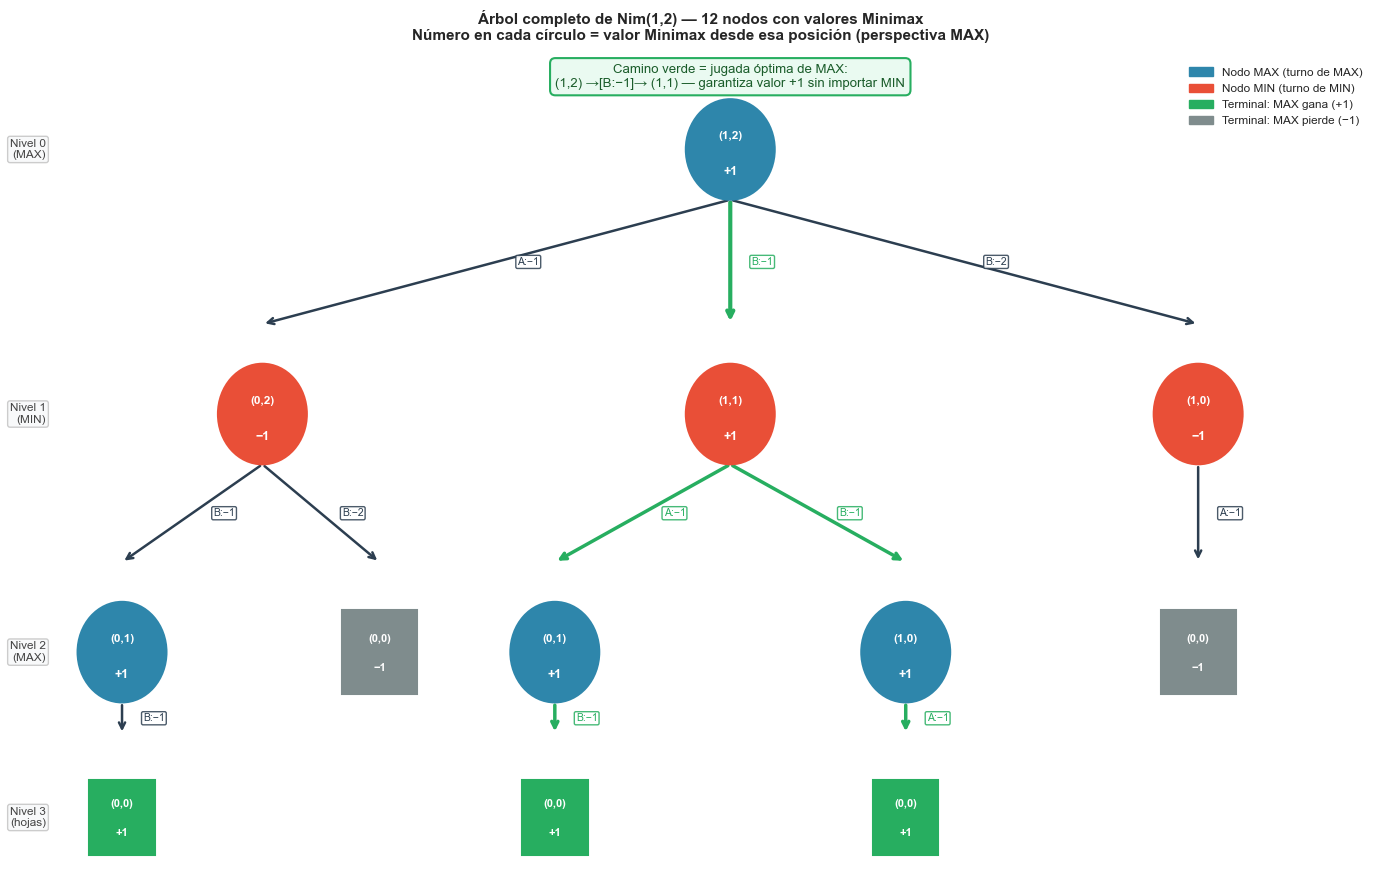

In [18]:
def visualizar_nim12():
    """
    Visualiza el arbol completo de Nim(1,2) con valores minimax.

    Distribucion de nodos:
      Nivel 0: (1,2)   — MAX
      Nivel 1: (0,2), (1,1), (1,0)   — MIN
      Nivel 2: hijos de cada nivel-1  — MAX
      Nivel 3: terminales (0,0)       — hojas
    """
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_xlim(-0.5, 11)
    ax.set_ylim(-1.0, 5.2)
    ax.axis('off')

    def draw_circle(x, y, label, color, val='', size=0.38):
        c = plt.Circle((x, y), size, color=color, zorder=3, linewidth=1.5,
                        edgecolor='white')
        ax.add_patch(c)
        ax.text(x, y + 0.10, label, ha='center', va='center',
                fontsize=8.5, fontweight='bold', color='white', zorder=4)
        if val:
            ax.text(x, y - 0.17, val, ha='center', va='center',
                    fontsize=9, color='white', zorder=4, fontweight='bold')

    def draw_square(x, y, label, color, size=0.32):
        rect = plt.Rectangle((x - size, y - size), 2 * size, 2 * size,
                              color=color, zorder=3, linewidth=1.5,
                              edgecolor='white')
        ax.add_patch(rect)
        for i, line in enumerate(label.split('\n')):
            ax.text(x, y + 0.1 - i * 0.22, line, ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white', zorder=4)

    def draw_edge(x1, y1, x2, y2, label='', color='#2C3E50', lw=1.8,
                  offset_x=0.18):
        ax.annotate('', xy=(x2, y2 + 0.38), xytext=(x1, y1 - 0.38),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw),
                    zorder=2)
        if label:
            mx = (x1 + x2) / 2 + offset_x
            my = (y1 + y2) / 2
            ax.text(mx, my, label, ha='left', va='center',
                    fontsize=7.5, color=color,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              ec=color, alpha=0.85))

    OPT   = COLORS["optimal"]
    EDGE  = COLORS["edge"]
    MAX_C = COLORS["max"]
    MIN_C = COLORS["min"]
    WIN   = COLORS["win"]
    LOSE  = COLORS["lose"]

    # ── Nivel 0: raíz (1,2) ──────────────────────────────────────────────────
    draw_circle(5.5, 4.5, '(1,2)', MAX_C, '+1')

    # ── Nivel 1: tres hijos de (1,2) ─────────────────────────────────────────
    # Acción A-1 → (0,2):  pila A retira 1
    # Acción B-1 → (1,1):  pila B retira 1  ← ÓPTIMA
    # Acción B-2 → (1,0):  pila B retira 2
    draw_edge(5.5, 4.5, 1.5, 2.8, 'A:−1', EDGE)
    draw_edge(5.5, 4.5, 5.5, 2.8, 'B:−1', OPT, lw=3.0)
    draw_edge(5.5, 4.5, 9.5, 2.8, 'B:−2', EDGE)

    draw_circle(1.5, 2.5, '(0,2)', MIN_C, '−1')
    draw_circle(5.5, 2.5, '(1,1)', MIN_C, '+1')
    draw_circle(9.5, 2.5, '(1,0)', MIN_C, '−1')

    # ── Nivel 2: hijos de cada nodo de nivel 1 ───────────────────────────────

    # (0,2): acciones B-1→(0,1), B-2→(0,0)
    draw_edge(1.5, 2.5, 0.3, 1.0, 'B:−1', EDGE)
    draw_edge(1.5, 2.5, 2.5, 1.0, 'B:−2', EDGE)
    draw_circle(0.3, 0.7, '(0,1)', MAX_C, '+1')
    draw_square(2.5, 0.7, '(0,0)\n−1', LOSE)

    # (1,1): acciones A-1→(0,1), B-1→(1,0)  — ambas óptimas para MIN
    draw_edge(5.5, 2.5, 4.0, 1.0, 'A:−1', OPT, lw=2.5)
    draw_edge(5.5, 2.5, 7.0, 1.0, 'B:−1', OPT, lw=2.5)
    draw_circle(4.0, 0.7, '(0,1)', MAX_C, '+1')
    draw_circle(7.0, 0.7, '(1,0)', MAX_C, '+1')

    # (1,0): acción A-1→(0,0)
    draw_edge(9.5, 2.5, 9.5, 1.0, 'A:−1', EDGE)
    draw_square(9.5, 0.7, '(0,0)\n−1', LOSE)

    # ── Nivel 3: terminales (0,0) desde los (0,1) de nivel 2 ─────────────────

    # Hijo de (0,1) que viene de (0,2)
    draw_edge(0.3, 0.7, 0.3, -0.3, 'B:−1', EDGE)
    draw_square(0.3, -0.55, '(0,0)\n+1', WIN, size=0.28)

    # Hijo de (0,1) que viene de (1,1)
    draw_edge(4.0, 0.7, 4.0, -0.3, 'B:−1', OPT, lw=2.5)
    draw_square(4.0, -0.55, '(0,0)\n+1', WIN, size=0.28)

    # Hijo de (1,0) que viene de (1,1)
    draw_edge(7.0, 0.7, 7.0, -0.3, 'A:−1', OPT, lw=2.5)
    draw_square(7.0, -0.55, '(0,0)\n+1', WIN, size=0.28)

    # ── Etiquetas de nivel ────────────────────────────────────────────────────
    for y_pos, lbl in [
        (4.5,  'Nivel 0\n(MAX)'),
        (2.5,  'Nivel 1\n(MIN)'),
        (0.7,  'Nivel 2\n(MAX)'),
        (-0.55,'Nivel 3\n(hojas)'),
    ]:
        ax.text(-0.35, y_pos, lbl, ha='right', va='center',
                fontsize=8.5, color='#444',
                bbox=dict(boxstyle='round,pad=0.2', fc='#F8F9FA', ec='#CCC'))

    # ── Anotación de camino óptimo ─────────────────────────────────────────────
    ax.text(5.5, 5.05,
            'Camino verde = jugada óptima de MAX:\n'
            '(1,2) →[B:−1]→ (1,1) — garantiza valor +1 sin importar MIN',
            ha='center', va='center', fontsize=9.5, color='#1A5C2A',
            bbox=dict(boxstyle='round,pad=0.4', fc='#EAFAF1', ec=OPT, lw=1.5))

    # ── Leyenda ────────────────────────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color=MAX_C, label='Nodo MAX (turno de MAX)'),
        mpatches.Patch(color=MIN_C, label='Nodo MIN (turno de MIN)'),
        mpatches.Patch(color=WIN,   label='Terminal: MAX gana (+1)'),
        mpatches.Patch(color=LOSE,  label='Terminal: MAX pierde (−1)'),
    ]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=8.5,
              framealpha=0.9, edgecolor='#CCC')

    ax.set_title(
        'Árbol completo de Nim(1,2) — 12 nodos con valores Minimax\n'
        'Número en cada círculo = valor Minimax desde esa posición (perspectiva MAX)',
        fontsize=11, fontweight='bold', pad=12
    )
    plt.tight_layout()
    plt.show()


visualizar_nim12()

---
## Parte 6: Verificación de la propiedad suma-cero

Un juego de **suma cero** tiene la propiedad:

$$\text{UTILITY}(s, MAX) + \text{UTILITY}(s, MIN) = 0 \quad \forall s \text{ terminal}$$

Es decir, lo que gana MAX lo pierde MIN exactamente. Esto es lo que justifica
que el adversario *minimice* la utilidad de MAX — maximizar la utilidad de MIN
es equivalente a minimizar la utilidad de MAX.

Vamos a verificar esta propiedad empíricamente para todos los estados terminales
de Nim y TicTacToe.

Para TicTacToe necesitamos definir `utilidad(s, 'MIN')`. En nuestro caso:
- Si X gana: utilidad(MAX) = +1, utilidad(MIN) = -1 → suma = 0 ✓
- Si O gana: utilidad(MAX) = -1, utilidad(MIN) = +1 → suma = 0 ✓
- Empate: utilidad(MAX) = 0, utilidad(MIN) = 0 → suma = 0 ✓

In [20]:
def recolectar_terminales(arbol):
    """Recorre el arbol y retorna lista de estados terminales."""
    if arbol['terminal']:
        return [arbol['estado']]
    result = []
    for _, hijo in arbol['hijos']:
        result.extend(recolectar_terminales(hijo))
    return result


def verificar_suma_cero_nim(juego, nombre):
    """
    En Nim, suma-cero significa:
      utilidad(s, MAX) + utilidad(s, MIN) = 0
    Para Nim la utilidad siempre es +1 o -1, así que:
      si MAX gana (+1), MIN pierde (-1), suma = 0.
    """
    arbol = construir_arbol(juego, juego.estado_inicial())
    terminales = recolectar_terminales(arbol)

    errores = 0
    conteo = {+1: 0, -1: 0}

    for estado in terminales:
        u_max = juego.utilidad(estado, 'MAX')
        u_min = -u_max   # propiedad suma-cero implica esto
        if u_max + u_min != 0:
            errores += 1
        conteo[u_max] = conteo.get(u_max, 0) + 1

    print(f"{nombre}:")
    print(f"  Terminales totales: {len(terminales)}")
    print(f"  MAX gana (+1):      {conteo.get(+1, 0)}")
    print(f"  MAX pierde (-1):    {conteo.get(-1, 0)}")
    if errores == 0:
        print(f"  Suma-cero verificada para todos los terminales.")
    else:
        print(f"  ERROR: {errores} terminales violan suma-cero!")
    print()


# Verificar para varios juegos Nim
for pilas, nombre in [([1, 2], "Nim(1,2)"),
                       ([2, 3], "Nim(2,3)"),
                       ([1, 2, 3], "Nim(1,2,3)")]:
    verificar_suma_cero_nim(Nim(pilas), nombre)

# TicTacToe
def verificar_suma_cero_ttt():
    ttt = TicTacToe()
    # Construir árbol hasta profundidad 4 para dar ejemplos
    # (árbol completo tarda varios segundos)
    print("TicTacToe (árbol completo, puede tardar unos segundos):")
    arbol_ttt = construir_arbol(ttt, ttt.estado_inicial())
    terminales = recolectar_terminales(arbol_ttt)
    conteo = {+1: 0, -1: 0, 0: 0}
    for estado in terminales:
        u = ttt.utilidad(estado)
        conteo[u] = conteo.get(u, 0) + 1
    print(f"  Terminales: {len(terminales)}")
    print(f"  X gana (+1): {conteo[+1]}, O gana (-1): {conteo[-1]}, Empate (0): {conteo[0]}")
    print(f"  Suma-cero verificada: siempre utilidad(MAX) + utilidad(MIN) = 0")

verificar_suma_cero_ttt()

Nim(1,2):
  Terminales totales: 5
  MAX gana (+1):      5
  MAX pierde (-1):    0
  Suma-cero verificada para todos los terminales.

Nim(2,3):
  Terminales totales: 37
  MAX gana (+1):      37
  MAX pierde (-1):    0
  Suma-cero verificada para todos los terminales.

Nim(1,2,3):
  Terminales totales: 182
  MAX gana (+1):      0
  MAX pierde (-1):    182
  Suma-cero verificada para todos los terminales.

TicTacToe (árbol completo, puede tardar unos segundos):
  Terminales: 255168
  X gana (+1): 131184, O gana (-1): 77904, Empate (0): 46080
  Suma-cero verificada: siempre utilidad(MAX) + utilidad(MIN) = 0


---
## Parte 7: Factor de ramificación efectivo

El **factor de ramificación** $b$ de un árbol de juego es el promedio de
hijos por nodo no terminal. Es una métrica clave porque el tiempo de Minimax
escala como $O(b^d)$ donde $d$ es la profundidad máxima.

Para Nim con pilas $(a, b)$, el factor de ramificación disminuye a medida
que el juego avanza (hay menos fichas y menos acciones posibles). El factor
de ramificación **efectivo** en la raíz es:

$$b_{\text{efectivo}} = \sum_i n_i \quad (\text{número total de acciones en el inicio})$$

Calculamos el factor de ramificación promedio en todo el árbol.

Juego            b en raíz   b promedio      Nodos
----------------------------------------------------
Nim(1,1)                 2         1.33          5
Nim(1,2)                 3         1.57         12
Nim(2,2)                 4         1.68         33
Nim(2,3)                 5         1.73         86
Nim(3,3)                 6         1.76        245
Nim(1,2,3)               6         1.68        447
Nim(2,3,4)               9         1.70     20,652


/var/folders/r7/k5t927sj03vdxdgxwbn3p2s80000gn/T/ipykernel_10452/1823122186.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(nombres_cfg, rotation=25, ha='right')
/var/folders/r7/k5t927sj03vdxdgxwbn3p2s80000gn/T/ipykernel_10452/1823122186.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(nombres_cfg, rotation=25, ha='right')


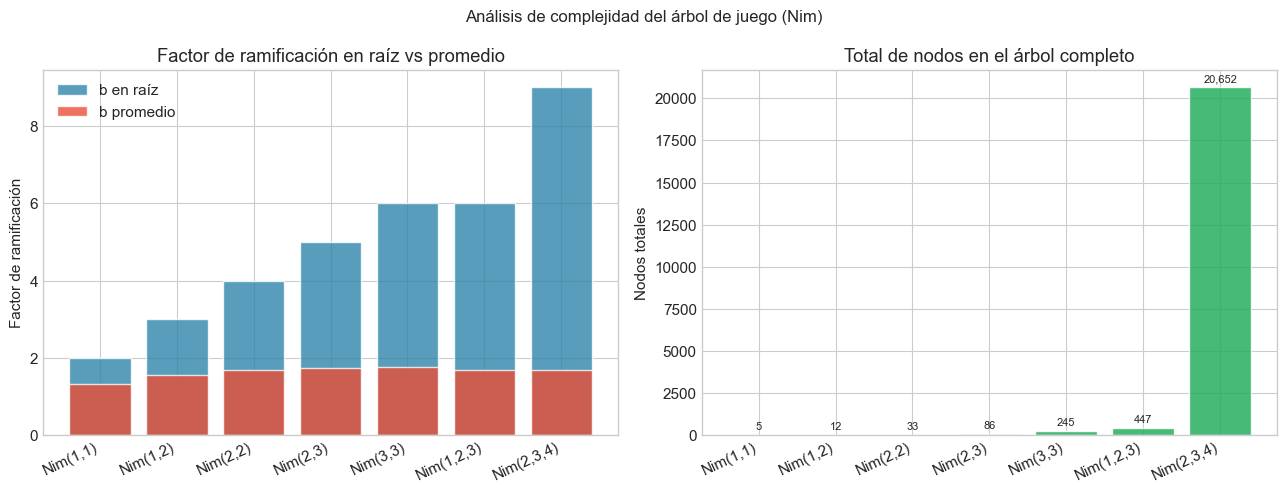

In [22]:
def factor_ramificacion_promedio(arbol):
    """
    Calcula el factor de ramificacion promedio en nodos no terminales.
    Retorna (promedio, lista de conteos por nivel).
    """
    total_hijos = 0
    total_nodos_internos = 0
    conteos_por_nivel = {}   # nivel → [num_hijos de cada nodo en ese nivel]

    def recorrer(nodo, nivel):
        nonlocal total_hijos, total_nodos_internos
        if nodo['terminal'] or not nodo['hijos']:
            return
        n_hijos = len(nodo['hijos'])
        total_hijos += n_hijos
        total_nodos_internos += 1
        if nivel not in conteos_por_nivel:
            conteos_por_nivel[nivel] = []
        conteos_por_nivel[nivel].append(n_hijos)
        for _, hijo in nodo['hijos']:
            recorrer(hijo, nivel + 1)

    recorrer(arbol, 0)
    promedio = total_hijos / total_nodos_internos if total_nodos_internos > 0 else 0
    return promedio, conteos_por_nivel


# Calcular para distintas configuraciones de Nim
configs = [
    ([1, 1], "Nim(1,1)"),
    ([1, 2], "Nim(1,2)"),
    ([2, 2], "Nim(2,2)"),
    ([2, 3], "Nim(2,3)"),
    ([3, 3], "Nim(3,3)"),
    ([1, 2, 3], "Nim(1,2,3)"),
    ([2, 3, 4], "Nim(2,3,4)"),
]

nombres_cfg = []
b_raiz_list = []
b_prom_list = []
total_nodos_list = []

print(f"{'Juego':<15} {'b en raíz':>10} {'b promedio':>12} {'Nodos':>10}")
print("-" * 52)

for pilas, nombre in configs:
    juego = Nim(pilas)
    s0 = juego.estado_inicial()
    b_raiz = len(juego.acciones(s0))
    arbol = construir_arbol(juego, s0)
    b_prom, _ = factor_ramificacion_promedio(arbol)
    total, _ = contar_nodos(arbol)

    nombres_cfg.append(nombre)
    b_raiz_list.append(b_raiz)
    b_prom_list.append(b_prom)
    total_nodos_list.append(total)

    print(f"{nombre:<15} {b_raiz:>10} {b_prom:>12.2f} {total:>10,}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(nombres_cfg, b_raiz_list, color=COLORS['max'], alpha=0.8,
            label='b en raíz', edgecolor='white')
axes[0].bar(nombres_cfg, b_prom_list, color=COLORS['min'], alpha=0.8,
            label='b promedio', edgecolor='white')
axes[0].set_title('Factor de ramificación en raíz vs promedio')
axes[0].set_ylabel('Factor de ramificación')
axes[0].set_xticklabels(nombres_cfg, rotation=25, ha='right')
axes[0].legend()

axes[1].bar(nombres_cfg, total_nodos_list, color=COLORS['win'], alpha=0.85,
            edgecolor='white')
axes[1].set_title('Total de nodos en el árbol completo')
axes[1].set_ylabel('Nodos totales')
axes[1].set_xticklabels(nombres_cfg, rotation=25, ha='right')
for i, v in enumerate(total_nodos_list):
    axes[1].text(i, v + max(total_nodos_list) * 0.01, f'{v:,}',
                 ha='center', va='bottom', fontsize=8)

plt.suptitle('Análisis de complejidad del árbol de juego (Nim)', fontsize=12)
plt.tight_layout()
plt.show()

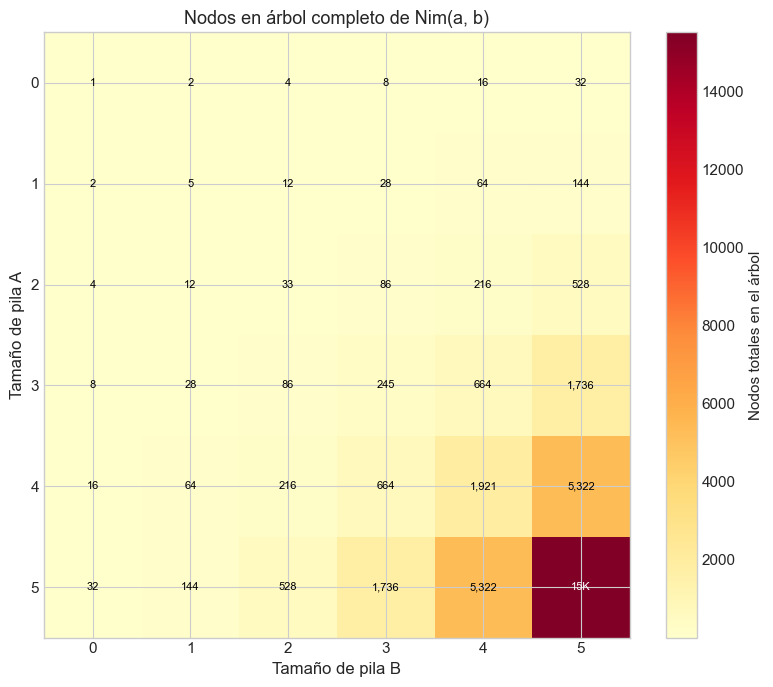

Observación: el crecimiento no es uniforme. Nim(a,b) con a=b
tiende a tener más nodos porque hay más acción simétrica posible.


In [23]:
# Heatmap: total de nodos para Nim(a, b) con a,b en 0..5

MAX_PILA = 6
grid_nodos = np.zeros((MAX_PILA, MAX_PILA), dtype=int)

for a in range(MAX_PILA):
    for b in range(MAX_PILA):
        nim_ab = Nim([a, b])
        s0 = nim_ab.estado_inicial()
        if nim_ab.terminal(s0):
            grid_nodos[a, b] = 1
        else:
            arbol = construir_arbol(nim_ab, s0)
            total, _ = contar_nodos(arbol)
            grid_nodos[a, b] = total

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(grid_nodos, cmap='YlOrRd', aspect='auto',
               interpolation='nearest')
plt.colorbar(im, ax=ax, label='Nodos totales en el árbol')

ax.set_xlabel('Tamaño de pila B', fontsize=12)
ax.set_ylabel('Tamaño de pila A', fontsize=12)
ax.set_title('Nodos en árbol completo de Nim(a, b)', fontsize=13)
ax.set_xticks(range(MAX_PILA))
ax.set_yticks(range(MAX_PILA))

for a in range(MAX_PILA):
    for b in range(MAX_PILA):
        val = grid_nodos[a, b]
        txt = f'{val:,}' if val < 10000 else f'{val//1000}K'
        ax.text(b, a, txt, ha='center', va='center', fontsize=8,
                color='black' if val < grid_nodos.max() * 0.6 else 'white')

plt.tight_layout()
plt.show()

print("Observación: el crecimiento no es uniforme. Nim(a,b) con a=b")
print("tiende a tener más nodos porque hay más acción simétrica posible.")

---
## Parte 8 (Ir más lejos): Juegos de N jugadores

Hasta ahora hemos asumido exactamente dos jugadores: MAX y MIN. En la realidad,
muchos juegos importantes tienen **N ≥ 3 jugadores**: póker, Catán, Go por equipos,
juegos de economía, etc.

La extensión a N jugadores requiere cambios conceptuales importantes:

1. **El estado debe rastrear quién mueve** (ya no es simple paridad).
2. **La utilidad es un vector**: $\mathbf{u}(s) = (u_1(s), u_2(s), \ldots, u_N(s))$.
3. **No hay suma cero en general**: pueden existir coaliciones y cooperación.
4. **Cada jugador maximiza su propia componente** del vector de utilidad.

El algoritmo Minimax generaliza al **Max-N**: en el turno del jugador $i$,
se elige la acción que maximiza $u_i$ asumiendo que todos los demás también
optimizan su propia utilidad.

### Ejemplo: Nim de 3 jugadores

Adaptamos Nim para tres jugadores. El jugador que toma la última ficha gana
(utilidad +1), los demás pierden (-1). La suma es -1 en lugar de 0.
(Esto es un juego de suma constante, no suma cero.)

In [25]:
class JuegoN(ABC):
    """
    Interfaz para juegos de N jugadores.

    La diferencia clave vs Juego: la utilidad retorna un diccionario
    {jugador_id → valor} en lugar de un escalar.
    """

    @abstractmethod
    def estado_inicial(self): pass

    @abstractmethod
    def jugador(self, estado):
        """Retorna el ID del jugador en turno (int 0..N-1)."""
        pass

    @abstractmethod
    def acciones(self, estado): pass

    @abstractmethod
    def resultado(self, estado, accion): pass

    @abstractmethod
    def terminal(self, estado): pass

    @abstractmethod
    def utilidad(self, estado):
        """Retorna dict {jugador_id: valor} en estados terminales."""
        pass


class Nim3(JuegoN):
    """
    Nim de 3 jugadores. Los jugadores se turnan en orden 0→1→2→0→...
    El jugador que toma la ultima ficha GANA (utilidad +1);
    los demas obtienen -1.

    Estado: (pila_A, pila_B, turno)  donde turno in {0, 1, 2}
    """

    def __init__(self, pilas_iniciales):
        self.pilas_iniciales = tuple(pilas_iniciales)
        self.N = 3

    def estado_inicial(self):
        return self.pilas_iniciales + (0,)   # jugador 0 empieza

    def jugador(self, estado):
        return estado[-1]   # último elemento es el turno

    def acciones(self, estado):
        pilas = estado[:-1]
        moves = []
        for i, pila in enumerate(pilas):
            for cant in range(1, pila + 1):
                moves.append((i, cant))
        return moves

    def resultado(self, estado, accion):
        pilas = list(estado[:-1])
        turno = estado[-1]
        pile_idx, amount = accion
        pilas[pile_idx] -= amount
        nuevo_turno = (turno + 1) % self.N
        return tuple(pilas) + (nuevo_turno,)

    def terminal(self, estado):
        pilas = estado[:-1]
        return all(p == 0 for p in pilas)

    def utilidad(self, estado):
        """
        El último movimiento fue hecho por el jugador ANTERIOR al turno actual.
        Ese jugador es quien tomó la última ficha → GANA (+1).
        Los otros dos reciben -1.
        """
        turno_actual = estado[-1]
        ganador = (turno_actual - 1) % self.N   # quien acaba de mover
        return {i: (+1 if i == ganador else -1) for i in range(self.N)}


# Test Nim3
nim3 = Nim3([1, 2])
s0 = nim3.estado_inicial()
print(f"Estado inicial Nim3(1,2): {s0}")
print(f"Jugador en turno: {nim3.jugador(s0)}")
print(f"Acciones: {nim3.acciones(s0)}")

# Simular secuencia
s1 = nim3.resultado(s0, (1, 1))  # Jugador 0 retira 1 de pila B
s2 = nim3.resultado(s1, (0, 1))  # Jugador 1 retira 1 de pila A
s3 = nim3.resultado(s2, (1, 1))  # Jugador 2 retira 1 de pila B (última)
print(f"\nEstado final: {s3}")
print(f"¿Terminal? {nim3.terminal(s3)}")
print(f"Utilidades: {nim3.utilidad(s3)}  (jugador 2 tomó la última ficha)")

Estado inicial Nim3(1,2): (1, 2, 0)
Jugador en turno: 0
Acciones: [(0, 1), (1, 1), (1, 2)]

Estado final: (0, 0, 0)
¿Terminal? True
Utilidades: {0: -1, 1: -1, 2: 1}  (jugador 2 tomó la última ficha)


In [26]:
def maxn(estado, juego_n):
    """
    Algoritmo Max-N para juegos de N jugadores.

    Cada jugador elige la accion que maximiza SU PROPIA componente
    del vector de utilidad.

    Retorna (vector_utilidades, accion_optima)
    donde vector_utilidades es un dict {jugador_id: valor}.
    """
    if juego_n.terminal(estado):
        return juego_n.utilidad(estado), None

    jugador_actual = juego_n.jugador(estado)
    mejor_util = None
    mejor_accion = None

    for accion in juego_n.acciones(estado):
        sucesor = juego_n.resultado(estado, accion)
        util_hijo, _ = maxn(sucesor, juego_n)

        # Jugador actual maximiza su propia utilidad
        if (mejor_util is None or
                util_hijo[jugador_actual] > mejor_util[jugador_actual]):
            mejor_util = util_hijo
            mejor_accion = accion

    return mejor_util, mejor_accion


# Aplicar Max-N a Nim3(1,2)
nim3_12 = Nim3([1, 2])
s0 = nim3_12.estado_inicial()
utilidades_opt, accion_opt = maxn(s0, nim3_12)

print(f"Nim3(1,2) — análisis Max-N:")
print(f"  Acción óptima del jugador 0: {accion_opt}")
print(f"  Vector de utilidades resultante: {utilidades_opt}")
print(f"  (jugador {max(utilidades_opt, key=utilidades_opt.get)} "
      f"gana con utilidad {max(utilidades_opt.values())} si todos juegan óptimo)")

print()
print("Nota clave sobre juegos de N > 2 jugadores:")
print("  En juegos de 2 jugadores, minimizar al oponente = maximizar a sí mismo.")
print("  Con N > 2 esto NO es cierto: dos jugadores pueden formar coaliciones")
print("  para perjudicar al tercero, incluso a costa de su propio beneficio.")
print("  Max-N no captura este comportamiento — asume que todos son 'egoístas'.")

Nim3(1,2) — análisis Max-N:
  Acción óptima del jugador 0: (0, 1)
  Vector de utilidades resultante: {0: -1, 1: 1, 2: -1}
  (jugador 1 gana con utilidad 1 si todos juegan óptimo)

Nota clave sobre juegos de N > 2 jugadores:
  En juegos de 2 jugadores, minimizar al oponente = maximizar a sí mismo.
  Con N > 2 esto NO es cierto: dos jugadores pueden formar coaliciones
  para perjudicar al tercero, incluso a costa de su propio beneficio.
  Max-N no captura este comportamiento — asume que todos son 'egoístas'.


---
## Resumen

En este notebook construimos los cimientos del módulo de búsqueda adversarial:

| Concepto | Lo que aprendimos |
|----------|-------------------|
| **Interfaz `Juego`** | 6 métodos: `estado_inicial`, `jugador`, `acciones`, `resultado`, `terminal`, `utilidad` |
| **Nim** | Juego de pilas con solución exacta; árbol pequeño pero ilustrativo |
| **TicTacToe** | Tablero 3×3; ≤362,880 nodos; estado como tupla de 9 strings |
| **Árbol de juego** | Niveles alternos MAX/MIN; hojas = utilidades |
| **Suma cero** | $u(MAX) + u(MIN) = 0$ para todo terminal; justifica minimax |
| **Complejidad** | Escala como $O(b^d)$; heatmap de nodos para Nim(a,b) |
| **Juegos de N jugadores** | Vector de utilidades; algoritmo Max-N |

### ¿Qué sigue?

En el **Notebook 02** implementamos los algoritmos que usan estos árboles:

- **Minimax**: recorre el árbol completo, garantiza la solución óptima.
- **Alpha-beta**: poda grandes porciones del árbol sin perder optimalidad.
- Experimentos de rendimiento: ¿cuánto ahorra alpha-beta? ¿depende del orden?